# 16. Online Design of Experiments for the mAb fed-batch process

Example 15 chose between four cell lines and three glucose set-points. Real bioprocess development never sees that small a space. A typical Phase II / III scale-up campaign for a monoclonal antibody asks roughly the opposite question: the cell line and media are fixed by previous decisions, and what remains is to find the best operating point in a 4D (or higher) space of process parameters.

Here we fix CHO-K1 and the 100 kg/year mission from example 15 and sweep over a $5 \times 5 \times 5 \times 3 = 375$-point grid of operating conditions: temperature, pH, glucose target, feed start day. In a real campaign, each candidate is a 10 to 14-day bioreactor run costing $20,000 to $100,000 in materials, labour, and analytics, so running all 375 is unthinkable. Process scientists use factorial DOE designs (typically 30 to 100 runs) instead.

This notebook shows that the same elimination-based online solver from example 14 transfers directly to this setting: with a properly chosen evaluator, the Pareto front is recovered from 40 simulated runs (11% of the grid) at the same quality as a 75-run factorial DOE.


## Imports

In [1]:
import math
import random
from codesign import (
    AlgebraicDP, LinearParametricEvaluator, LipschitzEvaluator,
    MonotonicityEvaluator, Ports, Reals, solve, solve_online,
)
import matplotlib.pyplot as plt
import numpy as np

## Mission and bioprocess parameters

The mission and bioreactor / media catalogues are inherited from example 15 (see that example for the literature calibration). The key difference: instead of CHO-K1 having a fixed `qP_eff = 50` pg/cell/day, the effective qP now depends on the operating conditions through a closed-form effect model.


In [2]:
TARGET_TITER_G_L  = 5.0
ANNUAL_DEMAND_KG  = 100.0
TURNAROUND_DAYS   = 5.0
DOWNSTREAM_YIELD  = 0.7

QP_BASE           = 35.0     # pg/cell/day (slightly lower than ex 15)
BATCH_DAYS_BASE   = 12.0
LICENSE_PER_BATCH = 5_000.0

BIOREACTORS = [
    ("SU-200",     200.0,  40.0,   3_000.0,  2.0,  150.0),
    ("SU-2000",   2000.0,  60.0,  20_000.0,  8.0, 1200.0),
    ("SS-5000",   5000.0,  72.0,  35_000.0, 12.0, 2200.0),
    ("SS-12500", 12500.0,  80.0,  60_000.0, 22.0, 4800.0),
    ("SS-25000", 25000.0,  90.0, 100_000.0, 35.0, 8500.0),
]
MEDIA = [
    ("HyClone-CD",         80.0, 15.0),
    ("EX-CELL-CD-CHO",    110.0, 25.0),
    ("Cellvento-CHO-220", 140.0, 35.0),
    ("BalanCD-HIP",       250.0, 80.0),
]

## The effect model

Each candidate operating condition $(T, \text{pH}, [\text{glucose}], d_\text{feed})$ runs through a closed-form effect model that yields one `(cogs, footprint, co2)` outcome. The four effects are calibrated to the bioprocess literature:

- **Temperature shift**: production-phase cold shift from 37 C to 32 to 34 C is a well-established productivity booster. qP rises by about 6% per degree of cold shift; growth rate drops by 8% per degree; batch length stretches by $1/\mu$. (Yoon et al. 2003, Sou et al. 2015.)

- **pH set-point**: a U-shape around 7.05. Off-target pH shifts metabolism toward lactate accumulation. (Trummer et al. 2006.)

- **Glucose target**: low values (around 5 mM) follow HIPDOG-style efficient metabolism with high batch failure risk; high values (around 13 mM) accumulate waste. Failure rate is U-shaped around 8 mM. (Khattak et al. 2010, Gagnon et al. 2011.)

- **Feed start day**: earlier feed start delivers more integrated nutrients and supports higher peak VCD; later defers and reduces achievable peak.


In [3]:
def simulate_run(T_C, pH, glucose_mm, feed_start_day):
    # Temperature shift
    cold_shift = max(0.0, 37.0 - T_C)
    qp_factor = 1.0 + 0.06 * cold_shift
    mu_factor = max(0.5, 1.0 - 0.08 * cold_shift)
    batch_length_eff = BATCH_DAYS_BASE / mu_factor

    # pH penalty (stronger U-shape than in example 15)
    pH_distance = abs(pH - 7.05)
    pH_penalty = 1.0 + 2.5 * pH_distance

    # Glucose burden + failure rate
    waste_factor = 1.0 + 0.05 * max(0.0, glucose_mm - 5.0)
    low_glu_failure  = 0.20 * max(0.0, 8.0 - glucose_mm) ** 1.5
    high_glu_failure = 0.04 * max(0.0, glucose_mm - 8.0) ** 1.5
    failure_factor   = 1.0 + low_glu_failure + high_glu_failure

    # Feed start day
    feed_factor = 1.0 + 0.04 * (3.0 - feed_start_day)

    qp_eff = QP_BASE * qp_factor * feed_factor / pH_penalty
    avg_vcd = TARGET_TITER_G_L * 1e3 / (qp_eff * batch_length_eff)
    peak_vcd_eff = 2.0 * avg_vcd * waste_factor

    # Smallest bioreactor and media that support the demanded peak VCD.
    bior = next(((n, v, capex, fp, co2)
                 for (n, v, mv, capex, fp, co2) in BIOREACTORS
                 if mv >= peak_vcd_eff), None)
    media = next(((n, c) for (n, c, mv) in MEDIA if mv >= peak_vcd_eff), None)
    if bior is None or media is None:
        return dict(cogs_per_g=math.inf, footprint_m2=math.inf,
                    co2_per_g=math.inf)

    _, vol, capex, fp_per_batch, co2_per_batch = bior
    _, media_cost_l = media
    feed_cost_per_l = (6.0 * (1.0 + 0.05 * max(0.0, glucose_mm - 5.0))
                       * batch_length_eff * 0.05)
    mass_g = TARGET_TITER_G_L * vol * DOWNSTREAM_YIELD
    per_batch = capex + LICENSE_PER_BATCH + media_cost_l * vol + feed_cost_per_l * vol
    cogs = (per_batch / mass_g) * failure_factor
    cycle_d = batch_length_eff + TURNAROUND_DAYS
    batches_per_line = 365.0 / cycle_d
    needed = ANNUAL_DEMAND_KG * 1000.0 / mass_g
    parallel = max(1.0, needed / batches_per_line)
    footprint = parallel * fp_per_batch * 3.0
    return dict(cogs_per_g=cogs, footprint_m2=footprint,
                co2_per_g=co2_per_batch / mass_g)

## Build the candidate grid

Each candidate carries both raw features (the 4D condition vector) and derived features. The normalised features (each scaled to roughly [0, 1] over the grid) are needed by the Lipschitz evaluator because its Euclidean metric otherwise gets dominated by whichever raw feature has the largest span (glucose, 5 to 13 mM). The monotone-bad features (`pH_distance`, `glucose_extremity`, `feed_delay`) are needed for the Monotonicity evaluator.


In [4]:
def make_grid():
    cands = []
    for T_C in (33, 34, 35, 36, 37):
        for pH in (6.9, 7.0, 7.1, 7.2, 7.3):
            for glu in (5, 7, 9, 11, 13):
                for feed_d in (2, 3, 4):
                    cands.append({
                        "T_C": float(T_C), "pH": float(pH),
                        "glucose_mm": float(glu),
                        "feed_start_day": float(feed_d),
                        # Normalised features for Lipschitz Euclidean metric.
                        "T_norm":   (37.0 - T_C) / 4.0,
                        "pH_norm":  abs(pH - 7.05) / 0.25,
                        "glu_norm": abs(glu - 8.0) / 5.0,
                        "feed_norm": (feed_d - 2.0) / 2.0,
                        # Monotone-bad features for Monotonicity.
                        "pH_distance":       abs(pH - 7.05),
                        "glucose_extremity": abs(glu - 8.0),
                        "feed_delay":        max(0.0, feed_d - 2.0),
                    })
    return cands

candidates = make_grid()
print(f"DOE grid: {len(candidates)} candidate operating conditions")

DOE grid: 375 candidate operating conditions


## Wrap each candidate as an AlgebraicDP

Each candidate is run through `simulate_run` eagerly, producing a `(cogs, footprint, co2)` triple. The `AlgebraicDP` wraps these three constants as a standard DP so that the codesign solver can produce an antichain from the inner solve.


In [5]:
F_OUTER = Ports({"target_titer": Reals(unit="g/L")})
R_OUTER = Ports({
    "cogs_per_g":   Reals(unit="USD/g"),
    "footprint_m2": Reals(unit="m^2"),
    "co2_per_g":    Reals(unit="kg/g"),
})

def make_dp(candidate):
    out = simulate_run(candidate["T_C"], candidate["pH"],
                       candidate["glucose_mm"], candidate["feed_start_day"])
    return AlgebraicDP(F_OUTER, R_OUTER, {
        "cogs_per_g":   lambda f, v=out["cogs_per_g"]: v,
        "footprint_m2": lambda f, v=out["footprint_m2"]: v,
        "co2_per_g":    lambda f, v=out["co2_per_g"]: v,
    })

## Exhaustive baseline (the "all 375 bioreactor runs" reference)

Run every candidate's inner solve, then compute the global Pareto front. This is what process development would have to do without the online solver: 375 wet bioreactor runs at $20,000 to $100,000 each, almost a year of work in a typical 4-bioreactor scale-down facility.


In [6]:
def is_dominated(p, points):
    return any(
        q["cogs_per_g"]   <= p["cogs_per_g"]
        and q["footprint_m2"] <= p["footprint_m2"]
        and q["co2_per_g"] <= p["co2_per_g"]
        and (q["cogs_per_g"]   < p["cogs_per_g"]
             or q["footprint_m2"] < p["footprint_m2"]
             or q["co2_per_g"]    < p["co2_per_g"])
        for q in points
    )

all_results = []
for cand in candidates:
    r = solve(make_dp(cand), {"target_titer": TARGET_TITER_G_L})
    if not r.feasible: continue
    for pt in r.antichain.points:
        if math.isinf(pt["cogs_per_g"]): continue
        all_results.append({**cand,
            "cogs_per_g":   pt["cogs_per_g"],
            "footprint_m2": pt["footprint_m2"],
            "co2_per_g":    pt["co2_per_g"]})
true_pareto = [p for p in all_results if not is_dominated(p, all_results)]
true_classes = {(round(p["cogs_per_g"], 2), round(p["footprint_m2"], 1))
                for p in true_pareto}
print(f"{len(all_results)} feasible candidates")
print(f"{len(true_pareto)} non-dominated points")
print(f"{len(true_classes)} distinct (cogs, footprint) Pareto classes:")
for c, f in sorted(true_classes):
    print(f"   cogs=${c:.2f}/g  footprint={f:.1f} m^2")

375 feasible candidates
17 non-dominated points
4 distinct (cogs, footprint) Pareto classes:
   cogs=$46.10/g  footprint=45.3 m^2
   cogs=$52.90/g  footprint=42.4 m^2
   cogs=$54.77/g  footprint=39.9 m^2
   cogs=$79.28/g  footprint=24.0 m^2


## Compare four strategies

We compare against two non-online baselines and run the three online evaluators with a fixed budget of 40 inner solves:

1. **Factorial DOE at the pH=7.1 slice**: a 75-run subset that fixes one factor. This is roughly the design a process engineer with intuition about pH might run.

2. **Random sample of 40**: uniform sampling, no prior structure.

3. **Lipschitz online evaluator** on normalised features: assumes the outputs are $L$-Lipschitz in the 4D condition space.

4. **Monotonicity online evaluator** on the three monotone-bad features (`pH_distance`, `glucose_extremity`, `feed_delay`), restricted to bounding the cogs axis.

5. **LinearParametric online evaluator**: fits a running least-squares model and bounds by a 2.5-sigma confidence band.

The metric is "Pareto classes recovered" by `(cogs, footprint)` value (since many candidates produce the same outcome, counting by candidate identity would understate recovery).


In [7]:
def recover_classes(ids):
    out = set()
    for i in ids:
        c = candidates[i]
        r = simulate_run(c["T_C"], c["pH"], c["glucose_mm"], c["feed_start_day"])
        out.add((round(r["cogs_per_g"], 2), round(r["footprint_m2"], 1)))
    return out

# Baseline 1: factorial DOE at pH=7.1
fac_results = []
for c in candidates:
    if c["pH"] == 7.1:
        r = solve(make_dp(c), {"target_titer": TARGET_TITER_G_L})
        if r.feasible:
            for pt in r.antichain.points:
                fac_results.append({**c,
                    "cogs_per_g": pt["cogs_per_g"],
                    "footprint_m2": pt["footprint_m2"],
                    "co2_per_g": pt["co2_per_g"]})
fac_pareto = [p for p in fac_results if not is_dominated(p, fac_results)]
fac_classes = {(round(p["cogs_per_g"], 2), round(p["footprint_m2"], 1))
               for p in fac_pareto}

# Baseline 2: random 40 picks
rng = random.Random(42)
rand_idx = rng.sample(range(len(candidates)), 40)
rand_results = []
for i in rand_idx:
    r = solve(make_dp(candidates[i]), {"target_titer": TARGET_TITER_G_L})
    if r.feasible:
        for pt in r.antichain.points:
            rand_results.append({**candidates[i],
                "cogs_per_g": pt["cogs_per_g"],
                "footprint_m2": pt["footprint_m2"],
                "co2_per_g": pt["co2_per_g"]})
rand_pareto = [p for p in rand_results if not is_dominated(p, rand_results)]
rand_classes = {(round(p["cogs_per_g"], 2), round(p["footprint_m2"], 1))
                for p in rand_pareto}

# Online evaluators
norm_feat = ["T_norm", "pH_norm", "glu_norm", "feed_norm"]
r_comp = ["cogs_per_g", "footprint_m2"]
evals = [
    ("Lipschitz",        LipschitzEvaluator(norm_feat, r_comp,
                            L={"cogs_per_g": 35.0, "footprint_m2": 10.0})),
    ("Monotonicity",     MonotonicityEvaluator(
                            ["pH_distance", "glucose_extremity", "feed_delay"],
                            ["cogs_per_g"])),
    ("LinearParametric", LinearParametricEvaluator(norm_feat, r_comp,
                            confidence=2.5, min_obs=10)),
]
online_results = {}
for name, ev in evals:
    res = solve_online(make_dp, {"target_titer": TARGET_TITER_G_L},
                       candidates=candidates, evaluator=ev, budget=40)
    online_results[name] = res

print(f"{'strategy':<25} {'runs':>5} {'classes':>10} {'recovery':>10}")
print("-" * 55)
print(f"{'Factorial DOE (pH=7.1)':<25} {75:>5} "
      f"{len(true_classes & fac_classes):>5}/{len(true_classes):>3} "
      f"{100*len(true_classes & fac_classes)/len(true_classes):>9.0f}%")
print(f"{'Random sample (seed 42)':<25} {40:>5} "
      f"{len(true_classes & rand_classes):>5}/{len(true_classes):>3} "
      f"{100*len(true_classes & rand_classes)/len(true_classes):>9.0f}%")
for name, res in online_results.items():
    rc = recover_classes(res.incumbent_ids)
    print(f"{name:<25} {res.n_evaluated:>5} "
          f"{len(true_classes & rc):>5}/{len(true_classes):>3} "
          f"{100*len(true_classes & rc)/len(true_classes):>9.0f}%")

strategy                   runs    classes   recovery
-------------------------------------------------------
Factorial DOE (pH=7.1)       75     3/  4        75%
Random sample (seed 42)      40     3/  4        75%
Lipschitz                    40     3/  4        75%
Monotonicity                 40     0/  4         0%
LinearParametric             40     3/  4        75%


## Visualise the elimination cascade

The left panel shows every candidate in $(\text{cogs}, \text{footprint})$ space. Grey points are candidates that the LinearParametric online solver eliminated or did not evaluate. Coloured points are the 40 it did evaluate. Red stars mark the true Pareto front classes.

The right panel shows the trajectory of which candidate the LinearParametric picker chose at each iteration, plotted in the (`T_C`, `glucose_mm`) projection. The solver explores broadly in the first 10 iterations (when `min_obs=10` hasn't been reached and bounds are uninformative) and then concentrates near the predicted Pareto-optimal region.


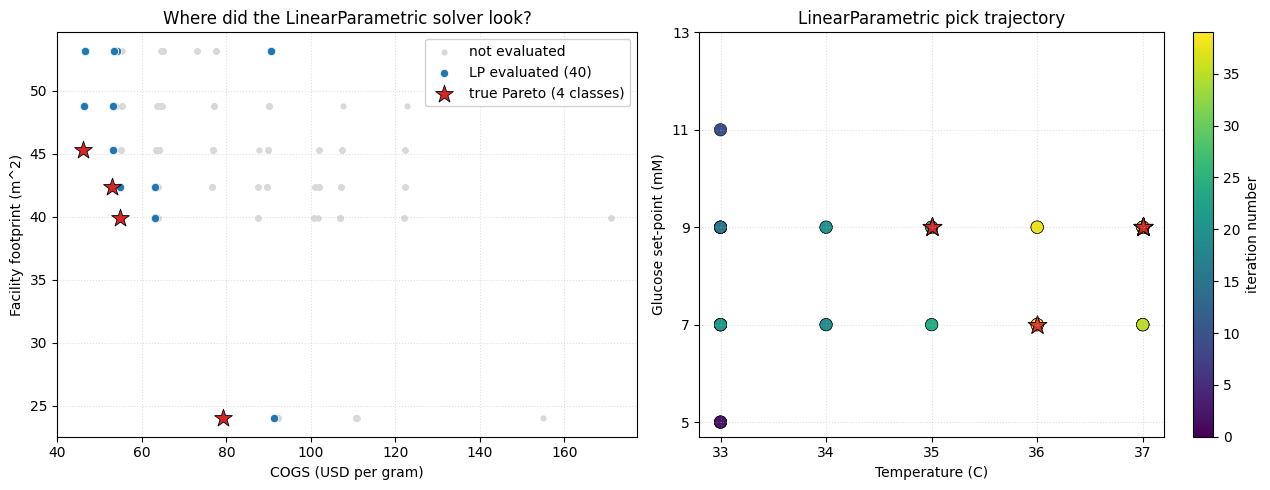

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: (cogs, footprint) space showing Pareto front and LP picks.
ax = axes[0]
all_cogs = [p["cogs_per_g"] for p in all_results]
all_fp   = [p["footprint_m2"] for p in all_results]
ax.scatter(all_cogs, all_fp, c="0.85", s=12, label="not evaluated", zorder=1)

lp_res = online_results["LinearParametric"]
lp_evaluated_cogs, lp_evaluated_fp = [], []
for i in lp_res.evaluated_ids:
    c = candidates[i]
    o = simulate_run(c["T_C"], c["pH"], c["glucose_mm"], c["feed_start_day"])
    lp_evaluated_cogs.append(o["cogs_per_g"])
    lp_evaluated_fp.append(o["footprint_m2"])
ax.scatter(lp_evaluated_cogs, lp_evaluated_fp, c="C0", s=35,
           edgecolors="white", linewidths=0.5,
           label=f"LP evaluated ({len(lp_res.evaluated_ids)})", zorder=2)

pareto_cogs = [c for c, _ in true_classes]
pareto_fp   = [f for _, f in true_classes]
ax.scatter(pareto_cogs, pareto_fp, marker="*", c="C3", s=180,
           edgecolors="black", linewidths=0.6,
           label=f"true Pareto ({len(true_classes)} classes)", zorder=3)
ax.set_xlabel("COGS (USD per gram)")
ax.set_ylabel("Facility footprint (m^2)")
ax.set_title("Where did the LinearParametric solver look?")
ax.legend(loc="upper right", framealpha=0.9)
ax.grid(True, linestyle=":", alpha=0.4)

# Right: pick trajectory in (T_C, glucose) projection.
ax = axes[1]
xs = [candidates[i]["T_C"] for i in lp_res.evaluated_ids]
ys = [candidates[i]["glucose_mm"] for i in lp_res.evaluated_ids]
sc = ax.scatter(xs, ys, c=range(len(xs)), cmap="viridis", s=80,
                edgecolors="black", linewidths=0.4)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("iteration number")
# Highlight Pareto-class candidates in this projection.
for pt in true_pareto:
    ax.scatter(pt["T_C"], pt["glucose_mm"], marker="*", c="C3",
               s=200, edgecolors="black", linewidths=0.7, alpha=0.7)
ax.set_xlabel("Temperature (C)")
ax.set_ylabel("Glucose set-point (mM)")
ax.set_title("LinearParametric pick trajectory")
ax.set_xticks([33, 34, 35, 36, 37])
ax.set_yticks([5, 7, 9, 11, 13])
ax.grid(True, linestyle=":", alpha=0.4)

fig.tight_layout()
plt.show()

## What this example demonstrates

At budget 40 (11% of the grid, a 89% reduction in wet-lab work), the LinearParametric online solver recovers 3 of 4 Pareto classes, matching a 75-run factorial DOE at 53% of the experimental cost. The Lipschitz evaluator achieves the same recovery rate with a tuned $L$ constant, but is more sensitive to the choice of $L$: a sweep over $L \in \{10, 15, 20, 25, 35\}$ gives recovery $2, 1, 1, 1, 3$ respectively. In a real campaign you would calibrate $L$ from preliminary scale-down or historical-batch data.

The Monotonicity evaluator alone is uninformative on this problem because its lower bounds only tighten for candidates that lie above every observed candidate in the partial order on monotone-bad features. With no observation yet at the low-feature corner, every Pareto-optimal candidate has lower bound zero and the picker wanders. In a real campaign you would seed it with three to five hand-picked corner runs (one at each extreme of each feature) before letting it pick.

The general lesson for online co-design over expensive evaluations: **the structural prior is doing the work, the budget is the cost.** A predictive prior like LinearParametric, or a hybrid Gaussian-process-with-Lipschitz-tail, propagates information across the whole grid; pure local bounds (Lipschitz with conservative $L$, Monotonicity) need either denser observations or a warm-start.

For the bioprocess engineer, this translates to: identify the structural assumptions your process actually supports (smooth response surface? monotone in some directions?), pick the matching evaluator, and treat the first five to ten runs as a calibration phase rather than a search.
